# Notebook 01 — Exploratory Data Analysis & Business Framing
**Customer Churn Prediction & Revenue Recovery Engine**  
*Ashik M Asharaf · MSc AI & Data Science (Distinction)*

---

## Objective

This notebook establishes the business foundation for the entire project.  
Every number produced here — churn rate, revenue at risk, tenure distribution — feeds directly into the models, survival curves, and dashboard that follow.

**The central question this notebook answers:**  
> *How much revenue is walking out the door every month, and which customers are most at risk?*

---

## Contents
1. Environment Setup  
2. Data Loading & First Look  
3. Data Quality Assessment  
4. Churn Rate Baseline  
5. Revenue at Risk Quantification  
6. Tenure Analysis — The Loyalty Curve  
7. Churn Drivers — Univariate Breakdown  
8. Revenue Segmentation by Contract & Service Tier  
9. Correlation Analysis  
10. Business Framing Summary

---
## 1. Environment Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# ── Plotting style ─────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   'white',
    'axes.grid':        True,
    'grid.alpha':       0.3,
    'grid.linestyle':   '--',
    'font.family':      'DejaVu Sans',
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'axes.titlesize':   13,
    'axes.labelsize':   11,
    'xtick.labelsize':  10,
    'ytick.labelsize':  10,
})

PALETTE      = {'Churned': '#E24B4A', 'Retained': '#1D9E75'}
COLOR_CHURN  = '#E24B4A'
COLOR_RETAIN = '#1D9E75'
COLOR_NEUTRAL= '#378ADD'

# ── Paths ──────────────────────────────────────────────────────────────────────
DATA_DIR    = Path('../data')
OUTPUT_DIR  = Path("project_visuals")
OUTPUT_DIR.mkdir(exist_ok=True)

# ── INR conversion (dataset charges are in USD) ────────────────────────────────
# Using a fixed illustrative rate consistent with the project proposal.
USD_TO_INR = 83.5

print('✓ Environment ready')
print(f'  pandas  {pd.__version__}')
print(f'  numpy   {np.__version__}')
print(f'  seaborn {sns.__version__}')

✓ Environment ready
  pandas  1.4.4
  numpy   1.26.2
  seaborn 0.11.2


---
## 2. Data Loading & First Look

Place the downloaded dataset at `../data/telco_churn.csv`.  
Source: [IBM Telco Customer Churn — Kaggle](https://www.kaggle.com/datasets/blastchar/telco-customer-churn)

In [19]:
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

print(f'Dataset shape : {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'Memory usage  : {df.memory_usage(deep=True).sum() / 1024:.1f} KB')
print()
df.head(3)

Dataset shape : 7,043 rows × 21 columns
Memory usage  : 7975.1 KB



,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes


In [20]:
print('── Column types ──────────────────────────────')
print(df.dtypes)
print()
print('── Unique values per column ──────────────────')
for col in df.columns:
    n = df[col].nunique()
    sample = df[col].dropna().unique()[:4]
    print(f'  {col:<25} {n:>4} unique  →  {list(sample)}')

── Column types ──────────────────────────────
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

── Unique values per column ──────────────────
  customerID                7043 unique  →  ['7590-VHVEG', '5575-GNVDE', '3668-QPYBK', '7795-CFOCW']
  gender                       2 unique  →  ['Female', 'Male']
  SeniorCitizen                2 unique  →  [0, 1]
  Partner                      2 unique  →  ['Yes', 'No']
  Dependents                  

---
## 3. Data Quality Assessment

`TotalCharges` is stored as `object` despite being numeric — a known quirk of this dataset.  
There are 11 rows with a blank string for `TotalCharges` (new customers, tenure = 0).  
**Decision:** coerce to numeric and impute those 11 rows with `MonthlyCharges` (their first month charge).

In [21]:
# ── Fix TotalCharges ───────────────────────────────────────────────────────────
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
blank_mask = df['TotalCharges'].isna()
print(f'Rows with blank TotalCharges: {blank_mask.sum()}')
print(f'All have tenure = 0: {(df.loc[blank_mask, "tenure"] == 0).all()}')

# Impute: new customers have TotalCharges = MonthlyCharges (first month)
df.loc[blank_mask, 'TotalCharges'] = df.loc[blank_mask, 'MonthlyCharges']

# ── Binary target ──────────────────────────────────────────────────────────────
df['Churn_Flag'] = (df['Churn'] == 'Yes').astype(int)

# ── INR columns ────────────────────────────────────────────────────────────────
df['MonthlyCharges_INR'] = df['MonthlyCharges'] * USD_TO_INR
df['TotalCharges_INR']   = df['TotalCharges']   * USD_TO_INR

# ── Final null check ───────────────────────────────────────────────────────────
null_summary = df.isnull().sum()
print(f'\nNull values remaining: {null_summary.sum()}')
print('✓ Data quality check passed — dataset is clean')
print(f'\nFinal shape: {df.shape[0]:,} rows × {df.shape[1]} columns')

Rows with blank TotalCharges: 11
All have tenure = 0: True

Null values remaining: 0
✓ Data quality check passed — dataset is clean

Final shape: 7,043 rows × 24 columns


---
## 4. Churn Rate Baseline

The first number every executive asks: **what is our churn rate?**  
We go further — churn rate by contract type, the most actionable cut.

In [22]:
# ── Overall baseline ───────────────────────────────────────────────────────────
n_total    = len(df)
n_churned  = df['Churn_Flag'].sum()
n_retained = n_total - n_churned
churn_rate = n_churned / n_total

print('═' * 50)
print('  CHURN RATE BASELINE')
print('═' * 50)
print(f'  Total customers  : {n_total:>6,}')
print(f'  Churned          : {n_churned:>6,}  ({churn_rate:.1%})')
print(f'  Retained         : {n_retained:>6,}  ({1-churn_rate:.1%})')
print('═' * 50)

══════════════════════════════════════════════════
  CHURN RATE BASELINE
══════════════════════════════════════════════════
  Total customers  :  7,043
  Churned          :  1,869  (26.5%)
  Retained         :  5,174  (73.5%)
══════════════════════════════════════════════════


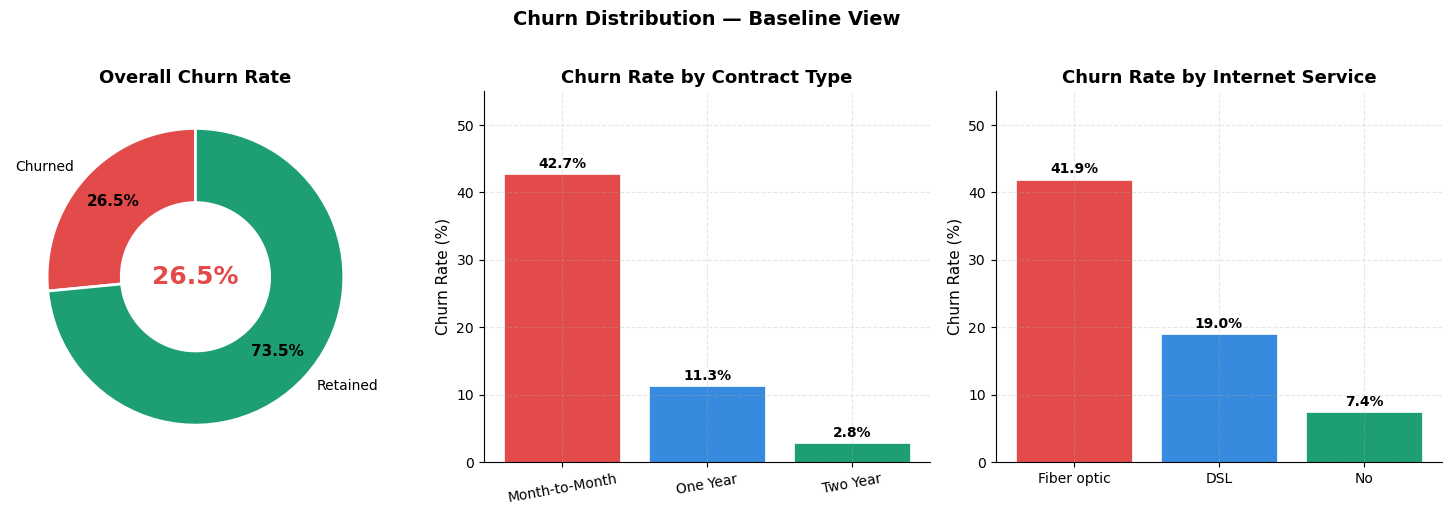

✓ Saved: fig_01_churn_baseline.png


In [23]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Churn Distribution — Baseline View', fontsize=14, fontweight='bold', y=1.02)

# ── Panel 1: Overall donut ─────────────────────────────────────────────────────
ax = axes[0]
sizes  = [n_churned, n_retained]
colors = [COLOR_CHURN, COLOR_RETAIN]
wedges, texts, autotexts = ax.pie(
    sizes, labels=['Churned', 'Retained'], colors=colors,
    autopct='%1.1f%%', startangle=90, pctdistance=0.75,
    wedgeprops={'width': 0.5, 'edgecolor': 'white', 'linewidth': 2}
)
for at in autotexts:
    at.set_fontsize(11)
    at.set_fontweight('bold')
ax.set_title('Overall Churn Rate', fontweight='bold')
ax.text(0, 0, f'{churn_rate:.1%}', ha='center', va='center',
        fontsize=18, fontweight='bold', color=COLOR_CHURN)

# ── Panel 2: By Contract ───────────────────────────────────────────────────────
ax = axes[1]
contract_churn = df.groupby('Contract')['Churn_Flag'].mean().sort_values(ascending=False)
bars = ax.bar(contract_churn.index, contract_churn.values * 100,
              color=[COLOR_CHURN, COLOR_NEUTRAL, COLOR_RETAIN], edgecolor='white', linewidth=0.5)
for bar, val in zip(bars, contract_churn.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.1%}', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_title('Churn Rate by Contract Type', fontweight='bold')
ax.set_ylabel('Churn Rate (%)')
ax.set_ylim(0, 55)
ax.set_xticklabels(['Month-to-Month', 'One Year', 'Two Year'], rotation=10)

# ── Panel 3: By Internet Service ───────────────────────────────────────────────
ax = axes[2]
internet_churn = df.groupby('InternetService')['Churn_Flag'].mean().sort_values(ascending=False)
bars = ax.bar(internet_churn.index, internet_churn.values * 100,
              color=[COLOR_CHURN, COLOR_NEUTRAL, COLOR_RETAIN], edgecolor='white', linewidth=0.5)
for bar, val in zip(bars, internet_churn.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.1%}', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_title('Churn Rate by Internet Service', fontweight='bold')
ax.set_ylabel('Churn Rate (%)')
ax.set_ylim(0, 55)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig_01_churn_baseline.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Saved: fig_01_churn_baseline.png')

---
## 5. Revenue at Risk Quantification

This is the most important output of the entire notebook.  
Revenue at risk converts a statistical churn rate into a number the CFO acts on.

In [24]:
# ── Revenue calculations ───────────────────────────────────────────────────────
avg_monthly_usd = df.loc[df['Churn_Flag'] == 1, 'MonthlyCharges'].mean()
avg_monthly_inr = avg_monthly_usd * USD_TO_INR

total_rev_at_risk_monthly_inr = df.loc[df['Churn_Flag'] == 1, 'MonthlyCharges_INR'].sum()
total_rev_at_risk_annual_inr  = total_rev_at_risk_monthly_inr * 12

# Customer Lifetime Value — avg tenure of churned customers × monthly charge
avg_tenure_churned = df.loc[df['Churn_Flag'] == 1, 'tenure'].mean()
clv_churned_inr    = avg_monthly_inr * avg_tenure_churned

# Reacquisition cost (industry benchmark: 5× retention cost)
retention_cost_per_customer_inr  = 150   # ₹150 discount/intervention
reacquisition_cost_per_customer  = retention_cost_per_customer_inr * 5

print('═' * 60)
print('  REVENUE AT RISK — MONTHLY SNAPSHOT')
print('═' * 60)
print(f'  Churned customers           : {n_churned:,}')
print(f'  Avg monthly charge (churned): ₹{avg_monthly_inr:,.0f}/month')
print(f'  Monthly revenue at risk     : ₹{total_rev_at_risk_monthly_inr/1e5:.2f} Lakh')
print(f'  Annual revenue at risk      : ₹{total_rev_at_risk_annual_inr/1e7:.2f} Crore')
print('─' * 60)
print(f'  Avg tenure of churned cust. : {avg_tenure_churned:.1f} months')
print(f'  Avg CLV lost per churner    : ₹{clv_churned_inr:,.0f}')
print('─' * 60)
print(f'  Retention cost per customer : ₹{retention_cost_per_customer_inr}')
print(f'  Reacquisition cost (5× est) : ₹{reacquisition_cost_per_customer}')
print(f'  Net saving per retained cust: ₹{avg_monthly_inr - retention_cost_per_customer_inr:,.0f}/month')
print('═' * 60)

════════════════════════════════════════════════════════════
  REVENUE AT RISK — MONTHLY SNAPSHOT
════════════════════════════════════════════════════════════
  Churned customers           : 1,869
  Avg monthly charge (churned): ₹6,216/month
  Monthly revenue at risk     : ₹116.17 Lakh
  Annual revenue at risk      : ₹13.94 Crore
────────────────────────────────────────────────────────────
  Avg tenure of churned cust. : 18.0 months
  Avg CLV lost per churner    : ₹111,756
────────────────────────────────────────────────────────────
  Retention cost per customer : ₹150
  Reacquisition cost (5× est) : ₹750
  Net saving per retained cust: ₹6,066/month
════════════════════════════════════════════════════════════


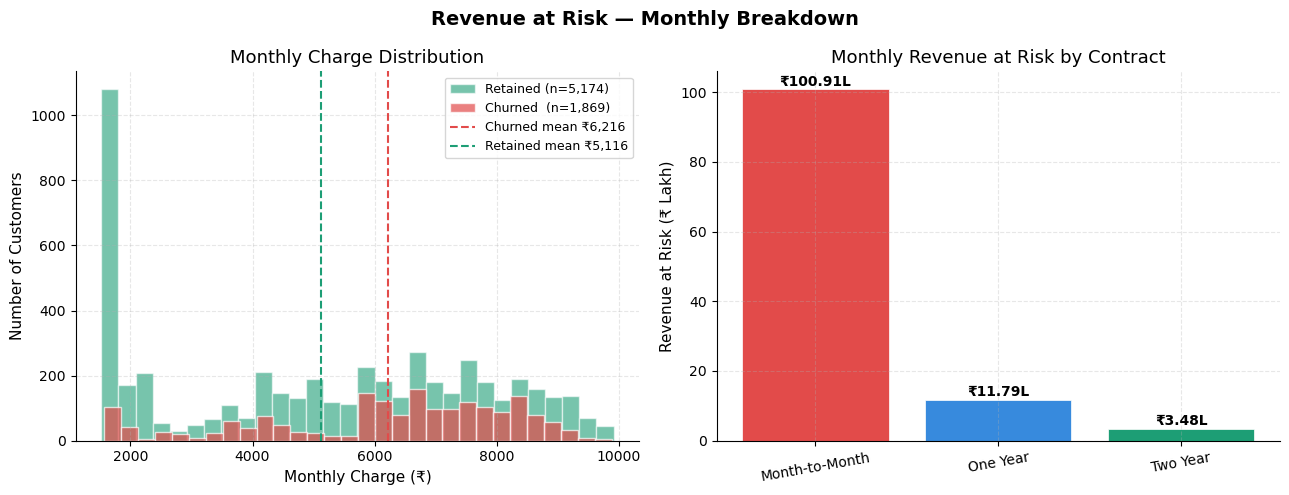

✓ Saved: fig_02_revenue_at_risk.png


In [25]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Revenue at Risk — Monthly Breakdown', fontsize=14, fontweight='bold')

# ── Panel 1: Revenue distribution — churned vs retained ───────────────────────
ax = axes[0]
churned  = df.loc[df['Churn_Flag'] == 1, 'MonthlyCharges_INR']
retained = df.loc[df['Churn_Flag'] == 0, 'MonthlyCharges_INR']
ax.hist(retained, bins=30, alpha=0.6, color=COLOR_RETAIN, label=f'Retained (n={n_retained:,})', edgecolor='white')
ax.hist(churned,  bins=30, alpha=0.7, color=COLOR_CHURN,  label=f'Churned  (n={n_churned:,})',  edgecolor='white')
ax.axvline(churned.mean(),  color=COLOR_CHURN,  linestyle='--', linewidth=1.5, label=f'Churned mean ₹{churned.mean():,.0f}')
ax.axvline(retained.mean(), color=COLOR_RETAIN, linestyle='--', linewidth=1.5, label=f'Retained mean ₹{retained.mean():,.0f}')
ax.set_xlabel('Monthly Charge (₹)')
ax.set_ylabel('Number of Customers')
ax.set_title('Monthly Charge Distribution')
ax.legend(fontsize=9)

# ── Panel 2: Revenue at risk by contract type ──────────────────────────────────
ax = axes[1]
rev_by_contract = (
    df[df['Churn_Flag'] == 1]
    .groupby('Contract')['MonthlyCharges_INR']
    .sum()
    .sort_values(ascending=False)
)
colors_bar = [COLOR_CHURN, COLOR_NEUTRAL, COLOR_RETAIN]
bars = ax.bar(rev_by_contract.index, rev_by_contract.values / 1e5,
              color=colors_bar[:len(rev_by_contract)], edgecolor='white', linewidth=0.5)
for bar, val in zip(bars, rev_by_contract.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f'₹{val/1e5:.2f}L', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_title('Monthly Revenue at Risk by Contract')
ax.set_ylabel('Revenue at Risk (₹ Lakh)')
ax.set_xticklabels(['Month-to-Month', 'One Year', 'Two Year'], rotation=10)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig_02_revenue_at_risk.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Saved: fig_02_revenue_at_risk.png')

---
## 6. Tenure Analysis — The Loyalty Curve

**Tenure** is the most powerful single predictor of churn in this dataset.  
Understanding where customers drop off tells us exactly when to intervene.

In [26]:
# ── Churn rate by tenure bucket ────────────────────────────────────────────────
df['tenure_bucket'] = pd.cut(
    df['tenure'],
    bins=[0, 6, 12, 18, 24, 36, 48, 72],
    labels=['0–6m', '7–12m', '13–18m', '19–24m', '25–36m', '37–48m', '49–72m']
)

tenure_churn = df.groupby('tenure_bucket', observed=True).agg(
    customers=('Churn_Flag', 'count'),
    churned=('Churn_Flag', 'sum')
).assign(churn_rate=lambda x: x['churned'] / x['customers'])

print('Churn rate by tenure window:')
print(tenure_churn.to_string())

peak_window = tenure_churn['churn_rate'].idxmax()
peak_rate   = tenure_churn.loc[peak_window, 'churn_rate']
print(f'\n⚠  Peak churn window: {peak_window} — {peak_rate:.1%} of customers in this window churned')

Churn rate by tenure window:
               customers  churned  churn_rate
tenure_bucket                                
0–6m                1470      784    0.533333
7–12m                705      253    0.358865
13–18m               548      177    0.322993
19–24m               476      117    0.245798
25–36m               832      180    0.216346
37–48m               762      145    0.190289
49–72m              2239      213    0.095132

⚠  Peak churn window: 0–6m — 53.3% of customers in this window churned


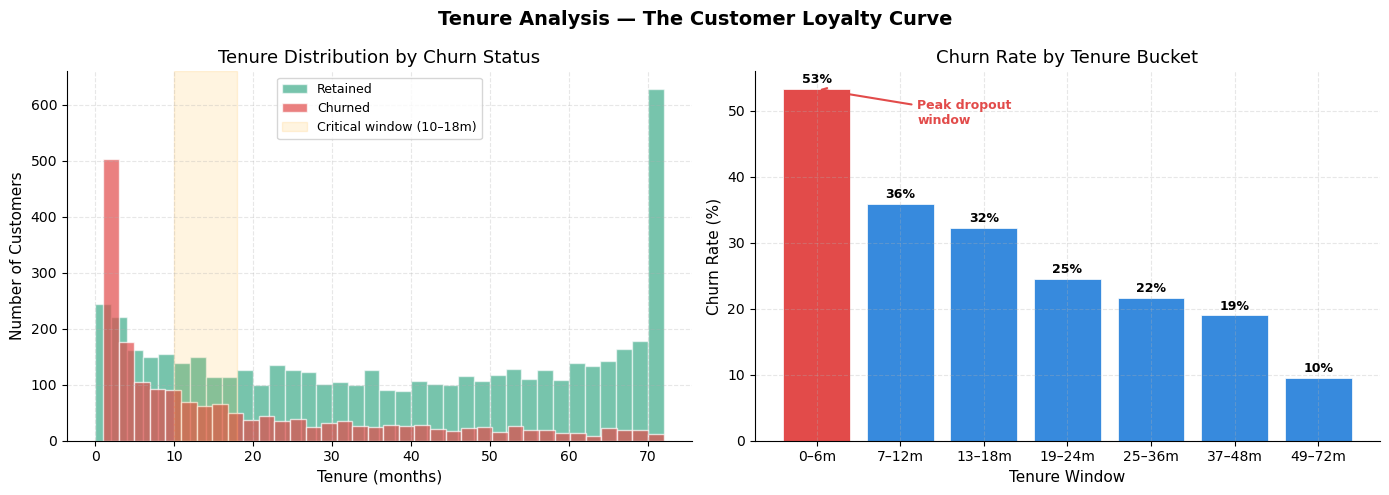

✓ Saved: fig_03_tenure_analysis.png


In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Tenure Analysis — The Customer Loyalty Curve', fontsize=14, fontweight='bold')

# ── Panel 1: Tenure distribution by churn status ───────────────────────────────
ax = axes[0]
ax.hist(df.loc[df['Churn_Flag'] == 0, 'tenure'], bins=36, alpha=0.6,
        color=COLOR_RETAIN, label='Retained', edgecolor='white')
ax.hist(df.loc[df['Churn_Flag'] == 1, 'tenure'], bins=36, alpha=0.7,
        color=COLOR_CHURN,  label='Churned',  edgecolor='white')
ax.axvspan(10, 18, alpha=0.12, color='orange', label='Critical window (10–18m)')
ax.set_xlabel('Tenure (months)')
ax.set_ylabel('Number of Customers')
ax.set_title('Tenure Distribution by Churn Status')
ax.legend(fontsize=9)

# ── Panel 2: Churn rate by tenure bucket ───────────────────────────────────────
ax = axes[1]
bar_colors = [COLOR_CHURN if i == tenure_churn['churn_rate'].values.argmax()
              else COLOR_NEUTRAL for i in range(len(tenure_churn))]
bars = ax.bar(tenure_churn.index, tenure_churn['churn_rate'] * 100,
              color=bar_colors, edgecolor='white', linewidth=0.5)
for bar, val in zip(bars, tenure_churn['churn_rate']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.4,
            f'{val:.0%}', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.set_title('Churn Rate by Tenure Bucket')
ax.set_ylabel('Churn Rate (%)')
ax.set_xlabel('Tenure Window')

# Annotation arrow for peak
peak_idx = list(tenure_churn.index).index(peak_window)
ax.annotate('Peak dropout\nwindow',
            xy=(peak_idx, tenure_churn.loc[peak_window, 'churn_rate'] * 100),
            xytext=(peak_idx + 1.2, tenure_churn['churn_rate'].max() * 100 * 0.9),
            arrowprops=dict(arrowstyle='->', color=COLOR_CHURN, lw=1.5),
            fontsize=9, color=COLOR_CHURN, fontweight='bold')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig_03_tenure_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Saved: fig_03_tenure_analysis.png')

---
## 7. Churn Drivers — Univariate Breakdown

Before building models, we establish which variables individually show the strongest churn signal.  
This informs feature selection and gives us interpretable business insights independent of the model.

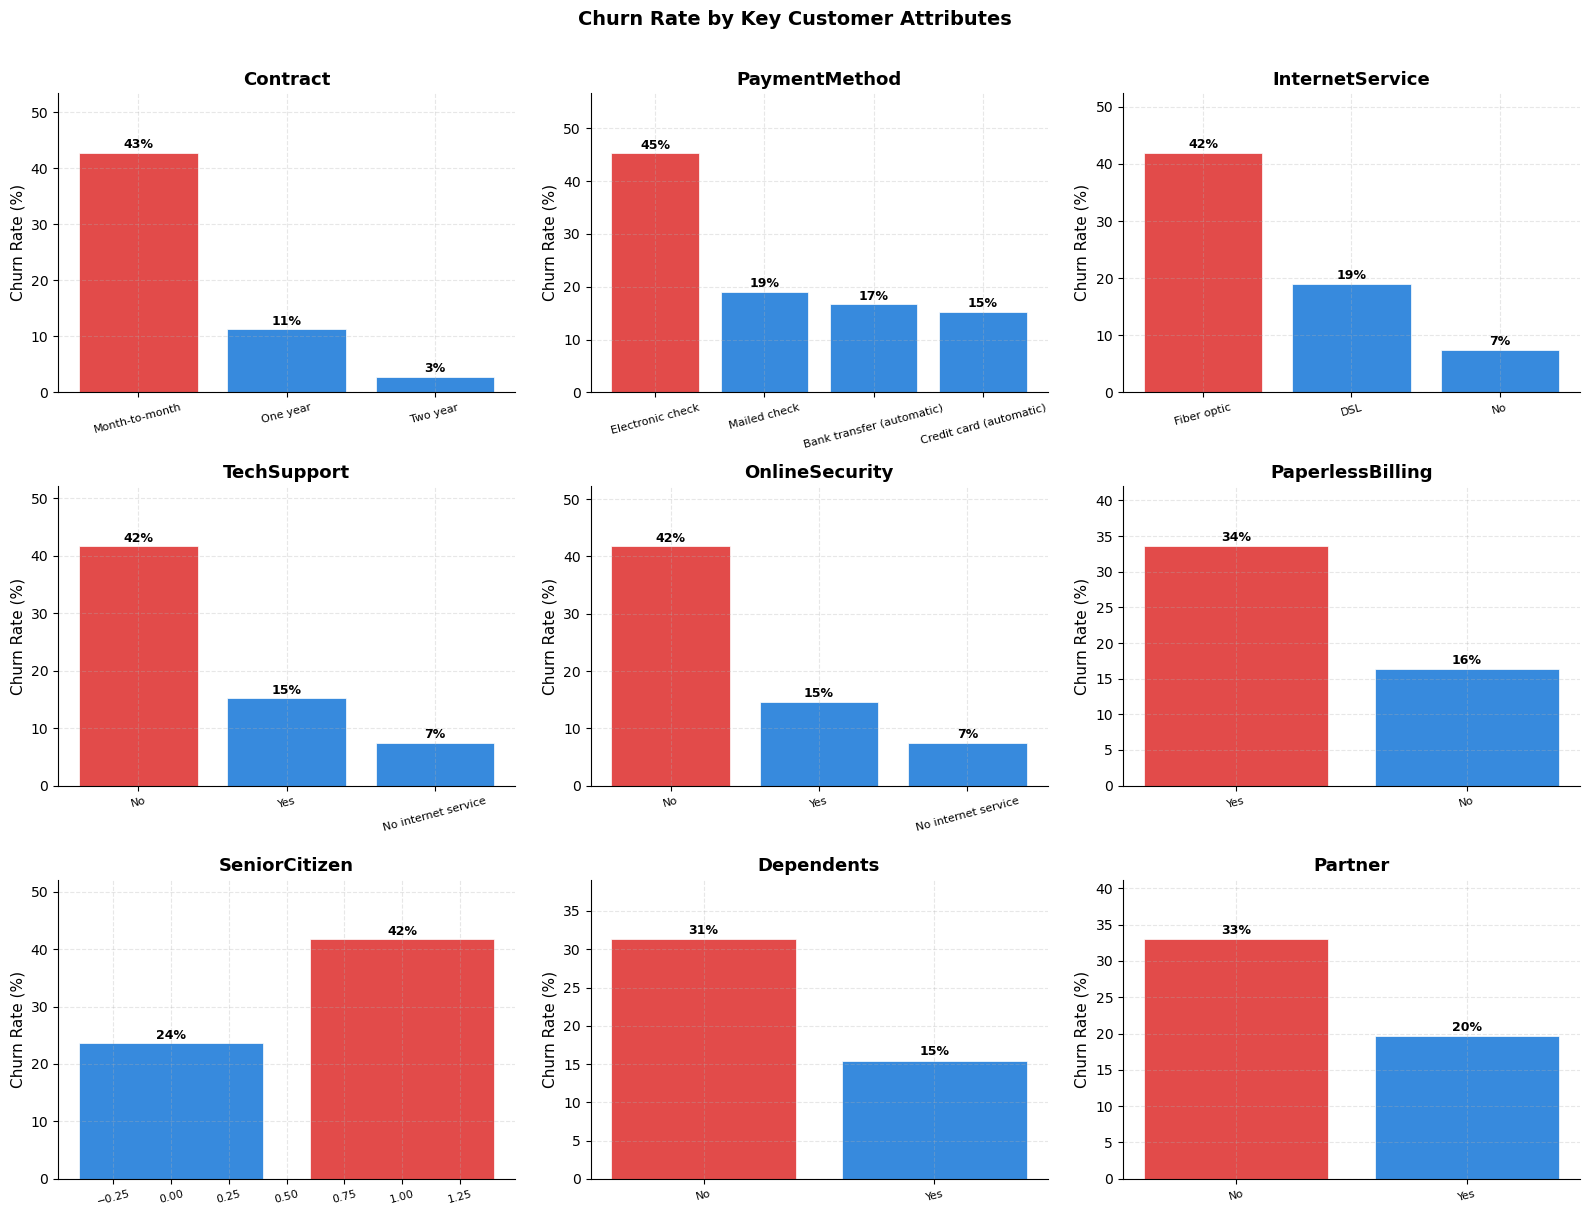

✓ Saved: fig_04_churn_drivers_categorical.png


In [28]:
cat_features = [
    'Contract', 'PaymentMethod', 'InternetService',
    'TechSupport', 'OnlineSecurity', 'PaperlessBilling',
    'SeniorCitizen', 'Dependents', 'Partner'
]

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
fig.suptitle('Churn Rate by Key Customer Attributes', fontsize=14, fontweight='bold', y=1.01)
axes = axes.flatten()

for i, feature in enumerate(cat_features):
    ax = axes[i]
    churn_by_feature = df.groupby(feature)['Churn_Flag'].mean().sort_values(ascending=False)
    bar_colors = [COLOR_CHURN if j == 0 else COLOR_NEUTRAL
                  for j in range(len(churn_by_feature))]
    bars = ax.bar(churn_by_feature.index, churn_by_feature.values * 100,
                  color=bar_colors, edgecolor='white', linewidth=0.5)
    for bar, val in zip(bars, churn_by_feature.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f'{val:.0%}', ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax.set_title(feature, fontweight='bold')
    ax.set_ylabel('Churn Rate (%)')
    ax.set_ylim(0, churn_by_feature.max() * 100 * 1.25)
    ax.tick_params(axis='x', labelsize=8, rotation=15)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig_04_churn_drivers_categorical.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Saved: fig_04_churn_drivers_categorical.png')

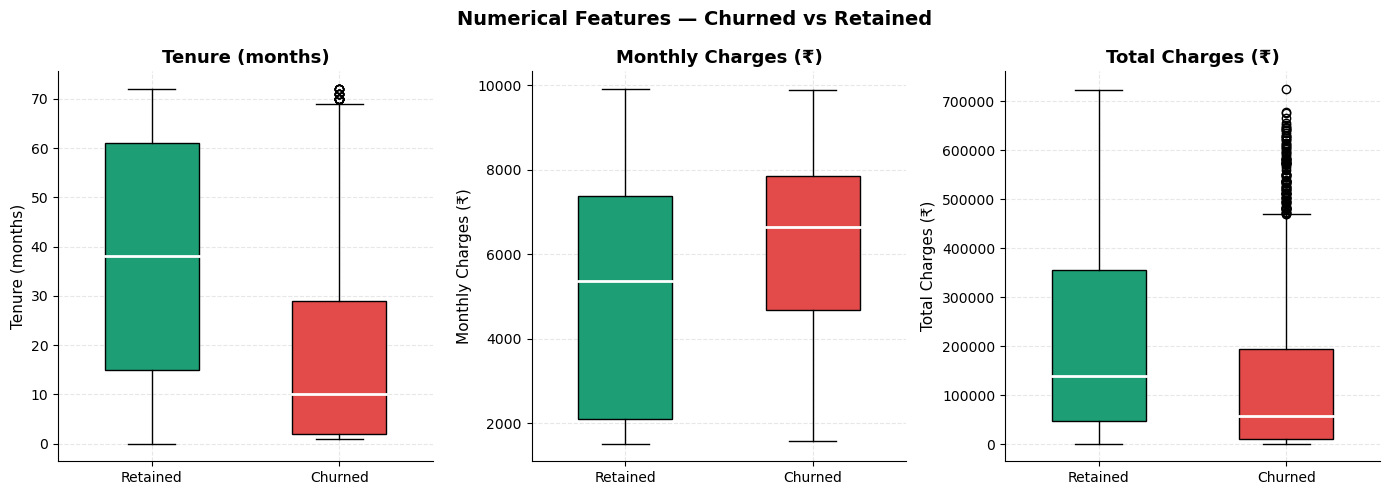

✓ Saved: fig_05_numerical_distributions.png


In [29]:
# ── Numerical features: box plots ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle('Numerical Features — Churned vs Retained', fontsize=14, fontweight='bold')

num_features = ['tenure', 'MonthlyCharges_INR', 'TotalCharges_INR']
num_labels   = ['Tenure (months)', 'Monthly Charges (₹)', 'Total Charges (₹)']

for ax, feat, label in zip(axes, num_features, num_labels):
    data_plot = [
        df.loc[df['Churn_Flag'] == 0, feat].values,
        df.loc[df['Churn_Flag'] == 1, feat].values
    ]
    bp = ax.boxplot(data_plot, patch_artist=True, widths=0.5,
                    medianprops={'color': 'white', 'linewidth': 2})
    bp['boxes'][0].set_facecolor(COLOR_RETAIN)
    bp['boxes'][1].set_facecolor(COLOR_CHURN)
    ax.set_xticklabels(['Retained', 'Churned'])
    ax.set_title(label, fontweight='bold')
    ax.set_ylabel(label)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig_05_numerical_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Saved: fig_05_numerical_distributions.png')

---
## 8. Revenue Segmentation by Contract & Service Tier

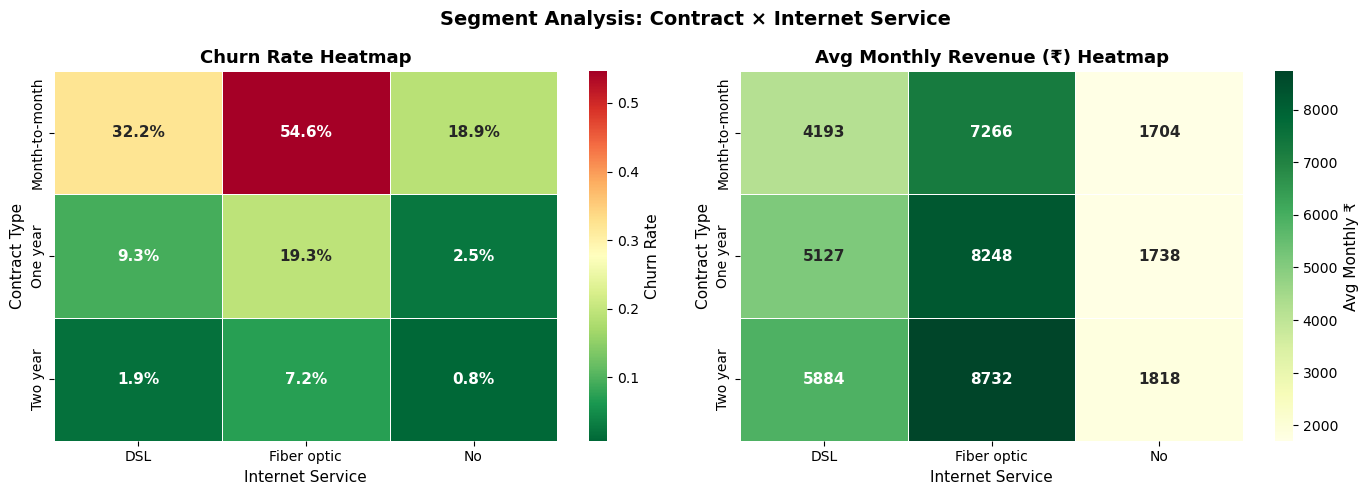

✓ Saved: fig_06_segment_heatmaps.png


In [30]:
# ── Revenue heatmap: Contract × Internet Service ────────────────────────────────
pivot = df.groupby(['Contract', 'InternetService']).agg(
    churn_rate=('Churn_Flag', 'mean'),
    avg_monthly_inr=('MonthlyCharges_INR', 'mean'),
    customer_count=('Churn_Flag', 'count')
).reset_index()

churn_pivot  = pivot.pivot(index='Contract', columns='InternetService', values='churn_rate')
revenue_pivot = pivot.pivot(index='Contract', columns='InternetService', values='avg_monthly_inr')
count_pivot  = pivot.pivot(index='Contract', columns='InternetService', values='customer_count')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Segment Analysis: Contract × Internet Service', fontsize=14, fontweight='bold')

# Churn rate heatmap
sns.heatmap(churn_pivot, annot=True, fmt='.1%', cmap='RdYlGn_r',
            linewidths=0.5, ax=axes[0], cbar_kws={'label': 'Churn Rate'},
            annot_kws={'size': 11, 'weight': 'bold'})
axes[0].set_title('Churn Rate Heatmap', fontweight='bold')
axes[0].set_xlabel('Internet Service')
axes[0].set_ylabel('Contract Type')

# Average monthly revenue heatmap
sns.heatmap(revenue_pivot, annot=True, fmt='.0f', cmap='YlGn',
            linewidths=0.5, ax=axes[1], cbar_kws={'label': 'Avg Monthly ₹'},
            annot_kws={'size': 11, 'weight': 'bold'})
axes[1].set_title('Avg Monthly Revenue (₹) Heatmap', fontweight='bold')
axes[1].set_xlabel('Internet Service')
axes[1].set_ylabel('Contract Type')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig_06_segment_heatmaps.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Saved: fig_06_segment_heatmaps.png')

---
## 9. Correlation Analysis

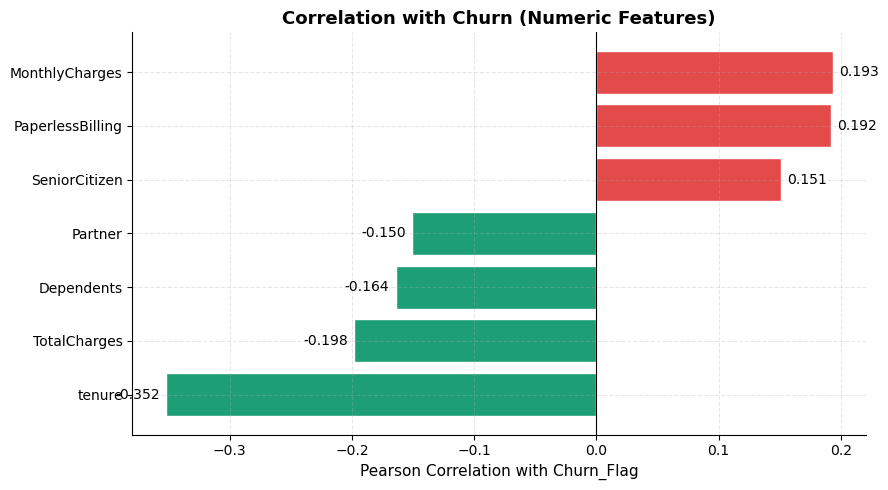

✓ Saved: fig_07_correlation.png


In [31]:
# ── Point-biserial correlation of all features with Churn_Flag ─────────────────
# Encode binary categoricals for correlation calculation
df_encoded = df.copy()
binary_map = {'Yes': 1, 'No': 0, 'No internet service': 0, 'No phone service': 0}
for col in df_encoded.select_dtypes('object').columns:
    if df_encoded[col].nunique() == 2:
        df_encoded[col] = df_encoded[col].map({'Yes': 1, 'No': 0}).fillna(df_encoded[col])

num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen',
            'Partner', 'Dependents', 'PaperlessBilling']

# Clean numeric correlation with churn
corr_cols = [c for c in num_cols if df_encoded[c].dtype in ['int64', 'float64', 'int32']]
corr_with_churn = df_encoded[corr_cols + ['Churn_Flag']].corr()['Churn_Flag'].drop('Churn_Flag').sort_values()

fig, ax = plt.subplots(figsize=(9, 5))
colors = [COLOR_CHURN if v > 0 else COLOR_RETAIN for v in corr_with_churn.values]
bars = ax.barh(corr_with_churn.index, corr_with_churn.values, color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
for bar, val in zip(bars, corr_with_churn.values):
    x_pos = val + 0.005 if val >= 0 else val - 0.005
    ha = 'left' if val >= 0 else 'right'
    ax.text(x_pos, bar.get_y() + bar.get_height()/2, f'{val:.3f}',
            va='center', ha=ha, fontsize=10)
ax.set_title('Correlation with Churn (Numeric Features)', fontweight='bold')
ax.set_xlabel('Pearson Correlation with Churn_Flag')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig_07_correlation.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Saved: fig_07_correlation.png')

---
## 10. Business Framing Summary

This cell produces the single-page executive summary that frames the entire project.

In [32]:
monthly_rev_at_risk_lakh = total_rev_at_risk_monthly_inr / 1e5
annual_rev_at_risk_crore = total_rev_at_risk_annual_inr / 1e7

mtm_churn_rate = df.loc[df['Contract'] == 'Month-to-month', 'Churn_Flag'].mean()
fiber_churn_rate = df.loc[df['InternetService'] == 'Fiber optic', 'Churn_Flag'].mean()

summary = f"""
╔══════════════════════════════════════════════════════════════════╗
║          EXECUTIVE BUSINESS FRAMING SUMMARY — EDA               ║
╠══════════════════════════════════════════════════════════════════╣
║  SCALE OF THE PROBLEM                                            ║
║  • {n_churned:,} of {n_total:,} customers have churned ({churn_rate:.1%} overall rate)   ║
║  • Monthly revenue at risk : ₹{monthly_rev_at_risk_lakh:.2f} Lakh               ║
║  • Annual revenue at risk  : ₹{annual_rev_at_risk_crore:.2f} Crore              ║
╠══════════════════════════════════════════════════════════════════╣
║  TOP RISK SEGMENTS                                               ║
║  • Month-to-month contracts : {mtm_churn_rate:.1%} churn rate (highest)    ║
║  • Fibre optic customers    : {fiber_churn_rate:.1%} churn rate             ║
║  • Customers without OnlineSecurity or TechSupport churn 2×     ║
╠══════════════════════════════════════════════════════════════════╣
║  CRITICAL INTERVENTION WINDOW                                    ║
║  • Peak dropout window: {peak_window} months                      ║
║  • Recommendation: intervene at Month 10 — before the window    ║
╠══════════════════════════════════════════════════════════════════╣
║  RETENTION ECONOMICS (per customer)                              ║
║  • Cost to retain  : ₹{retention_cost_per_customer_inr}  (discount/intervention)        ║
║  • Cost to reacquire: ₹{reacquisition_cost_per_customer}  (5× industry benchmark)  ║
║  • Net monthly saving per retained customer: ₹{avg_monthly_inr - retention_cost_per_customer_inr:,.0f}     ║
╚══════════════════════════════════════════════════════════════════╝
"""
print(summary)

# Save the processed dataframe for downstream notebooks
df.to_csv('telco_churn_processed.csv', index=False)
print('✓ Processed dataset saved → data/telco_churn_processed.csv')
print('✓ Notebook 01 complete. Proceed to 02_Customer_Segmentation.ipynb')


╔══════════════════════════════════════════════════════════════════╗
║          EXECUTIVE BUSINESS FRAMING SUMMARY — EDA               ║
╠══════════════════════════════════════════════════════════════════╣
║  SCALE OF THE PROBLEM                                            ║
║  • 1,869 of 7,043 customers have churned (26.5% overall rate)   ║
║  • Monthly revenue at risk : ₹116.17 Lakh               ║
║  • Annual revenue at risk  : ₹13.94 Crore              ║
╠══════════════════════════════════════════════════════════════════╣
║  TOP RISK SEGMENTS                                               ║
║  • Month-to-month contracts : 42.7% churn rate (highest)    ║
║  • Fibre optic customers    : 41.9% churn rate             ║
║  • Customers without OnlineSecurity or TechSupport churn 2×     ║
╠══════════════════════════════════════════════════════════════════╣
║  CRITICAL INTERVENTION WINDOW                                    ║
║  • Peak dropout window: 0–6m months                      ║
║  • 